In [1]:
pip install torch torchvision matplotlib numpy tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\Raghvendra Goyal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import torch                          # main deep learning library
import torch.nn as nn                 # neural network layers
import torch.optim as optim           # optimizers like Adam
from torch.utils.data import DataLoader, Dataset  # data loading
import torchvision.transforms as T    # image transformations
from torchvision.datasets import OxfordIIITPet    # dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm                 # progress bar during training

# use GPU if available, else CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", DEVICE)

Using: cuda


In [3]:
# Download dataset (first time lega thoda time)
raw_train = OxfordIIITPet(root="data", split="trainval",
                           target_types="segmentation", download=True)
raw_test  = OxfordIIITPet(root="data", split="test",
                           target_types="segmentation", download=True)

# ── Print Dataset Info ────────────────────────────────────────────────────
print("=" * 45)
print("       DATASET INFORMATION")
print("=" * 45)
print(f"  Dataset      : Oxford-IIIT Pet Dataset")
print(f"  Task         : Binary Segmentation")
print(f"  Train Samples: {len(raw_train)}")
print(f"  Test  Samples: {len(raw_test)}")
print(f"  Total Samples: {len(raw_train) + len(raw_test)}")
print(f"  Classes      : Foreground (Pet) / Background")
print(f"  Mask Values  : 1=Pet, 2=Background, 3=Border")
print("=" * 45)

# Show one sample image and mask
img, mask = raw_train[0]
print(f"\n  Sample Image Size : {img.size}")
print(f"  Sample Mask  Size : {mask.size}")
print(f"  Unique Mask Values: {np.unique(np.array(mask))}")

100%|██████████| 792M/792M [03:46<00:00, 3.49MB/s]  
100%|██████████| 19.2M/19.2M [00:04<00:00, 4.05MB/s]


       DATASET INFORMATION
  Dataset      : Oxford-IIIT Pet Dataset
  Task         : Binary Segmentation
  Train Samples: 3680
  Test  Samples: 3669
  Total Samples: 7349
  Classes      : Foreground (Pet) / Background
  Mask Values  : 1=Pet, 2=Background, 3=Border

  Sample Image Size : (394, 500)
  Sample Mask  Size : (394, 500)
  Unique Mask Values: [1 2 3]


In [4]:
class PetSegDataset(Dataset):
    def __init__(self, base_dataset, img_size=128):
        self.data     = base_dataset
        self.img_size = img_size

        # image transform: resize → tensor → normalize
        self.img_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225])
        ])
        # mask transform: only resize (no normalize)
        self.mask_tf = T.Resize((img_size, img_size),
                                 interpolation=T.InterpolationMode.NEAREST)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, mask = self.data[idx]

        img  = self.img_tf(img)

        mask = self.mask_tf(mask)
        mask = torch.tensor(np.array(mask), dtype=torch.long)

        # Convert to binary: pixel=1 means pet (foreground), rest=0
        binary_mask = (mask == 1).long()

        return img, binary_mask


# Create dataset objects
train_dataset = PetSegDataset(raw_train, img_size=128)
test_dataset  = PetSegDataset(raw_test,  img_size=128)

# Create DataLoaders (batches of 16)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

# Check one batch shape
imgs, masks = next(iter(train_loader))
print(f"Image batch shape : {imgs.shape}")   # [16, 3, 128, 128]
print(f"Mask  batch shape : {masks.shape}")  # [16, 128, 128]

Train batches : 230
Test  batches : 230
Image batch shape : torch.Size([16, 3, 128, 128])
Mask  batch shape : torch.Size([16, 128, 128])


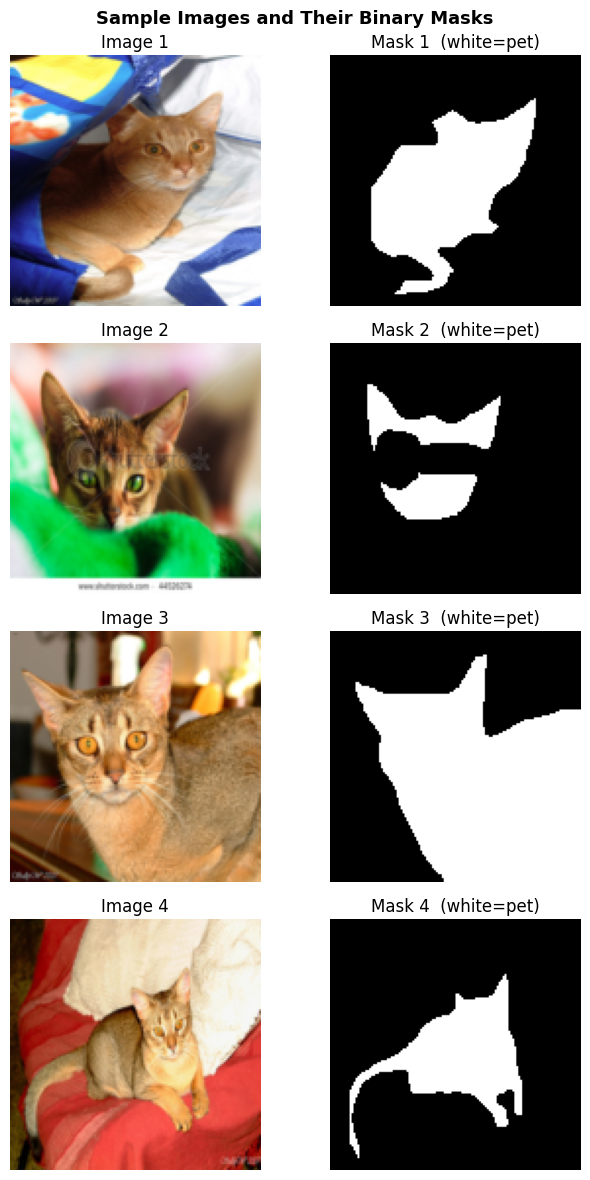

Saved → sample_images.png


In [5]:
def show_samples(dataset, n=4):
    fig, axes = plt.subplots(n, 2, figsize=(7, n * 3))
    fig.suptitle("Sample Images and Their Binary Masks", fontsize=13, fontweight='bold')

    for i in range(n):
        img, mask = dataset[i]

        # un-normalize image for display
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img_show = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

        axes[i, 0].imshow(img_show)
        axes[i, 0].set_title(f"Image {i+1}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask.numpy(), cmap="gray")
        axes[i, 1].set_title(f"Mask {i+1}  (white=pet)")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=100)
    plt.show()
    print("Saved → sample_images.png")

show_samples(train_dataset, n=4)

Build the U-Net Model
U-Net ke 3 parts hain:

Encoder — image ko compress karta hai (features sikhta hai)
Bottleneck — sabse deep part
Decoder — mask wapas banata hai (upsample karta hai)

Skip connections encoder aur decoder ko directly jodti hain taaki fine details na khoyen.

In [6]:
# ── Helper Block: two Conv layers ────────────────────────────────────────────
class ConvBlock(nn.Module):
    """Two (Conv → BatchNorm → ReLU) layers"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


# ── Encoder Block: ConvBlock + MaxPool ───────────────────────────────────────
class EncoderBlock(nn.Module):
    """Downsample: learn features, reduce spatial size by 2x"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2)  # halves height and width

    def forward(self, x):
        skip = self.conv(x)   # save this for skip connection
        down = self.pool(skip)
        return down, skip


# ── Decoder Block: Upsample + ConvBlock ──────────────────────────────────────
class DecoderBlock(nn.Module):
    """Upsample: double spatial size, combine with skip connection"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = ConvBlock(out_ch * 2, out_ch)  # *2 because of skip concat

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)  # concat skip connection
        return self.conv(x)


# ── Full U-Net ────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()

        # Encoder (going down)
        self.enc1 = EncoderBlock(in_channels, 64)
        self.enc2 = EncoderBlock(64, 128)
        self.enc3 = EncoderBlock(128, 256)
        self.enc4 = EncoderBlock(256, 512)

        # Bottleneck (deepest point)
        self.bottleneck = ConvBlock(512, 1024)

        # Decoder (going up)
        self.dec4 = DecoderBlock(1024, 512)
        self.dec3 = DecoderBlock(512,  256)
        self.dec2 = DecoderBlock(256,  128)
        self.dec1 = DecoderBlock(128,   64)

        # Final output layer → 1x1 conv gives class scores per pixel
        self.output_conv = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder path
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder path (skip connections passed in reverse)
        x = self.dec4(x, s4)
        x = self.dec3(x, s3)
        x = self.dec2(x, s2)
        x = self.dec1(x, s1)

        return self.output_conv(x)


# ── Create model and print summary ───────────────────────────────────────────
model = UNet(in_channels=3, num_classes=2).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 45)
print("       MODEL INFORMATION")
print("=" * 45)
print(f"  Model          : U-Net")
print(f"  Input Channels : 3 (RGB)")
print(f"  Output Classes : 2 (pet / background)")
print(f"  Total Params   : {total_params:,}")
print(f"  Trainable Params: {train_params:,}")
print("=" * 45)

# Test with a dummy input to confirm shapes work
dummy = torch.randn(2, 3, 128, 128).to(DEVICE)
out   = model(dummy)
print(f"\n  Input  Shape : {dummy.shape}")
print(f"  Output Shape : {out.shape}")   # should be [2, 2, 128, 128]

       MODEL INFORMATION
  Model          : U-Net
  Input Channels : 3 (RGB)
  Output Classes : 2 (pet / background)
  Total Params   : 31,037,698
  Trainable Params: 31,037,698

  Input  Shape : torch.Size([2, 3, 128, 128])
  Output Shape : torch.Size([2, 2, 128, 128])


In [7]:
criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=1e-3)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
                 optimizer, mode='min', patience=3, factor=0.5)

print("Loss Function : CrossEntropyLoss")
print("Optimizer     : Adam  (lr=0.001)")
print("LR Scheduler  : ReduceLROnPlateau (patience=3)")

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

In [ ]:
def compute_metrics(pred_mask, true_mask, eps=1e-7):
    """
    pred_mask : [B, H, W] — predicted class per pixel (0 or 1)
    true_mask : [B, H, W] — ground truth class per pixel (0 or 1)
    """
    pred = pred_mask.view(-1).float()
    true = true_mask.view(-1).float()

    # True Positive, False Positive, False Negative, True Negative
    TP = ((pred == 1) & (true == 1)).sum().float()
    FP = ((pred == 1) & (true == 0)).sum().float()
    FN = ((pred == 0) & (true == 1)).sum().float()
    TN = ((pred == 0) & (true == 0)).sum().float()

    # 1. Pixel Accuracy: how many pixels are correctly labeled
    pixel_acc = (TP + TN) / (TP + TN + FP + FN + eps)

    # 2. IoU (Intersection over Union): overlap / union
    iou = TP / (TP + FP + FN + eps)

    # 3. Dice Score (F1): 2 * overlap / (pred_size + true_size)
    dice = (2 * TP) / (2 * TP + FP + FN + eps)

    # 4. Precision: of all predicted foreground, how many are correct
    precision = TP / (TP + FP + eps)

    # 5. Recall: of all actual foreground, how many did we catch
    recall = TP / (TP + FN + eps)

    return {
        "Pixel Accuracy": pixel_acc.item(),
        "IoU"           : iou.item(),
        "Dice Score"    : dice.item(),
        "Precision"     : precision.item(),
        "Recall"        : recall.item()
    }

print("Metrics defined: Pixel Accuracy, IoU, Dice, Precision, Recall")

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for imgs, masks in tqdm(loader, desc="  Training", leave=False):
        imgs  = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()        # clear old gradients
        outputs = model(imgs)        # forward pass → [B, 2, H, W]
        loss = criterion(outputs, masks)  # compare with true masks
        loss.backward()              # backpropagation
        optimizer.step()             # update weights

        total_loss += loss.item()

    return total_loss / len(loader)  # average loss


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_metrics = {"Pixel Accuracy": 0, "IoU": 0,
                   "Dice Score": 0, "Precision": 0, "Recall": 0}

    with torch.no_grad():   # no gradient calculation during eval
        for imgs, masks in tqdm(loader, desc="  Evaluating", leave=False):
            imgs  = imgs.to(device)
            masks = masks.to(device)

            outputs = model(imgs)
            loss    = criterion(outputs, masks)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)  # pick class with highest score
            m = compute_metrics(preds.cpu(), masks.cpu())

            for k in all_metrics:
                all_metrics[k] += m[k]

    # Average over all batches
    n = len(loader)
    for k in all_metrics:
        all_metrics[k] /= n

    return total_loss / n, all_metrics

In [ ]:
EPOCHS = 10    # increase to 20-30 for better results

train_losses, val_losses = [], []
val_ious, val_dices      = [], []

print("=" * 55)
print("              TRAINING STARTED")
print("=" * 55)

for epoch in range(1, EPOCHS + 1):
    print(f"\n  Epoch [{epoch}/{EPOCHS}]")

    train_loss           = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_metrics = evaluate(model, test_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_ious.append(val_metrics["IoU"])
    val_dices.append(val_metrics["Dice Score"])

    print(f"  Train Loss     : {train_loss:.4f}")
    print(f"  Val   Loss     : {val_loss:.4f}")
    print(f"  Pixel Accuracy : {val_metrics['Pixel Accuracy']:.4f}")
    print(f"  IoU            : {val_metrics['IoU']:.4f}")
    print(f"  Dice Score     : {val_metrics['Dice Score']:.4f}")
    print(f"  Precision      : {val_metrics['Precision']:.4f}")
    print(f"  Recall         : {val_metrics['Recall']:.4f}")

print("\n" + "=" * 55)
print("              TRAINING COMPLETE")
print("=" * 55)

In [ ]:
print("\nRunning final evaluation on test set...")
_, final_metrics = evaluate(model, test_loader, criterion, DEVICE)

print("\n" + "=" * 45)
print("       FINAL EVALUATION RESULTS")
print("=" * 45)
for metric, value in final_metrics.items():
    bar_len = int(value * 20)
    bar     = "█" * bar_len + "░" * (20 - bar_len)
    print(f"  {metric:<16} : {value:.4f}  [{bar}]")
print("=" * 45)

In [ ]:
def visualize_predictions(model, dataset, device, n=4):
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(10, n * 3))
    fig.suptitle("Image  |  Ground Truth  |  Prediction", fontsize=13, fontweight='bold')

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    for i in range(n):
        img, true_mask = dataset[i]

        # Un-normalize image for display
        img_show = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

        # Get prediction
        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))   # add batch dim
            pred   = torch.argmax(output, dim=1).squeeze(0).cpu()

        axes[i, 0].imshow(img_show)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(true_mask.numpy(), cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred.numpy(), cmap="gray")
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig("predictions.png", dpi=100)
    plt.show()
    print("Saved → predictions.png")

visualize_predictions(model, test_dataset, DEVICE, n=4)

In [ ]:
torch.save(model.state_dict(), "unet_pet_segmentation.pth")
print("Model saved → unet_pet_segmentation.pth")

# To load later:
# model.load_state_dict(torch.load("unet_pet_segmentation.pth"))